# Advanced DiSC Stability Analysis Notebook

This notebook implements a realistic **Stability Index (SI)** model for the
Digital Skull Clamp (DiSC). It combines twisting moments, uneven pin depths,
and an optional global shear force so pin angles (`phis_deg`) matter.

## Mathematical Model & Key Formulas

1. **Moment about z-axis**  
$$
M_z = \sum_{i=1}^3 \bigl(\mathbf{r}_i \times \mathbf{F}_i\bigr)_z
$$

2. **Penetration depth** per pin and range:  
$$
d_i = k_{\rm depth} \; |F_i|,
\quad \Delta d = \max_i d_i - \min_i d_i
$$

3. **Global shear force** applied along +X so angles matter  
$$
\mathbf{F}_{\rm shear} = [F_{\rm shear}, 0, 0]
$$

4. **Stability Index (SI)**:  
$$
SI = \exp\biggl(-\frac{|M_z|}{M_{\rm crit}}\biggr) \times \exp\biggl(-\frac{\Delta d}{d_{\rm crit}}\biggr)
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def evaluate_clamp_basic(forces_N, phis_deg,
                         skull_R=85.0,
                         k_depth=0.04,
                         Mcrit=50.0,
                         dcrit=1.0,
                         F_shear=0.0):
    """
    Compute Stability Index (SI) for a three-pin clamp.
    Inputs:
      - forces_N: [F1, F2, F3] normal forces (N)
      - phis_deg: [ϕ1, ϕ2, ϕ3] pin angles (deg)
      - skull_R: radius (mm)
      - k_depth: mm per N
      - Mcrit: moment scale
      - dcrit: depth-scale
      - F_shear: global shear force along +X (N)
    Returns:
      - SI: stability index (0–1)
    """
    phis = np.deg2rad(phis_deg)
    r = np.stack([
        skull_R * np.cos(phis),
        skull_R * np.sin(phis),
        np.zeros_like(phis)
    ], axis=1)
    r_hat = r / np.linalg.norm(r, axis=1)[:, None]
    shear_vec = np.array([F_shear, 0.0, 0.0])
    forces = np.asarray(forces_N, float)
    F_vec = np.array([-forces[i] * r_hat[i] + shear_vec for i in range(3)])
    Mz = np.cross(r, F_vec)[:, 2].sum()
    depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))
    delta_d = depths.ptp()
    SI = np.exp(-abs(Mz) / Mcrit) * np.exp(-delta_d / dcrit)
    return SI


### How pin angles now matter
- We apply one **global shear force** along X instead of per-pin tangential.
- Different pin angles produce different twisting moments via `r × F_shear`.
- Now, when `F_shear > 0`, changing `phis_deg` yields different SI values.




In [4]:
# Test with and without shear, and two angle sets
for shear in (0.0, 10.0):
    print(f"F_shear = {shear} N")
    for phis in ([0, 120, 240], [0, 100, 260]):
        SI = evaluate_clamp_basic([100,100,100], phis, F_shear=shear)
        print(f"  phis={phis} -> SI = {SI:.3f}")

F_shear = 0.0 N
  phis=[0, 120, 240] -> SI = 1.000
  phis=[0, 100, 260] -> SI = 1.000
F_shear = 10.0 N
  phis=[0, 120, 240] -> SI = 0.549
  phis=[0, 100, 260] -> SI = 0.625


## Compare Stability Surfaces
Side-by-side 3D plots for Pin C fixed at 100 N.

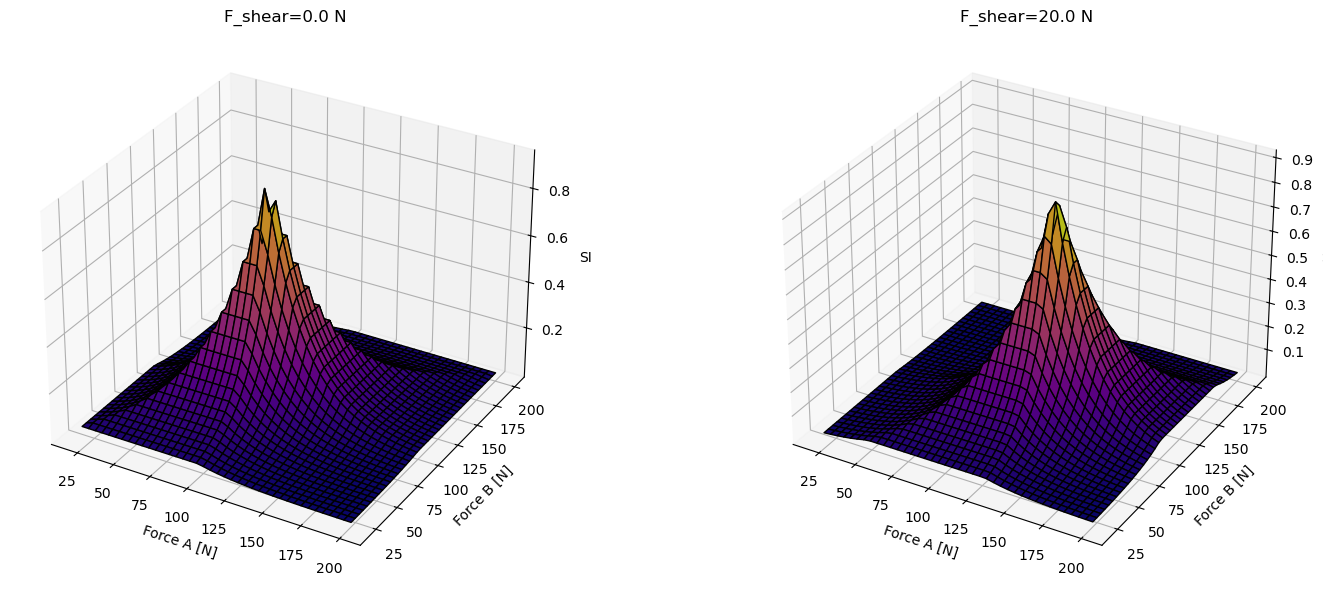

In [3]:
force_min, force_max, N = 20, 200, 40
fA = np.linspace(force_min, force_max, N)
fB = np.linspace(force_min, force_max, N)
FC = 100.0
fig = plt.figure(figsize=(16,6))
for idx, shear in enumerate((0.0, 20.0), start=1):
    ax = fig.add_subplot(1, 2, idx, projection='3d')
    FA, FB = np.meshgrid(fA, fB)
    Z = np.zeros_like(FA)
    for i in range(N):
        for j in range(N):
            Z[i,j] = evaluate_clamp_basic([FA[i,j], FB[i,j], FC], [0,120,240], F_shear=shear)
    norm_Z = (Z - Z.min())/(Z.max()-Z.min())
    colors = plt.cm.plasma(norm_Z)
    ax.plot_surface(FA, FB, Z, facecolors=colors, rstride=1, cstride=1, edgecolor='k')
    ax.set_title(f"F_shear={shear} N")
    ax.set_xlabel('Force A [N]')
    ax.set_ylabel('Force B [N]')
    ax.set_zlabel('SI')
plt.tight_layout()
plt.show()